<a href="https://colab.research.google.com/github/Dounia-Awni/Prediction-Of-Product-Sales/blob/main/Prediction_of_product_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sales

- Author: Donia Nassar

## Project Overview

This project focuses on predicting product sales for food items sold at various retail stores using machine learning techniques. It aims at providing insights into sales trends and helping businesses optimize inventory and pricing strategies.

Objective: Build accurate predictive models to forecast sales performance
Approach: Data exploration, feature engineering, and multiple regression algorithms.
The Data Dictionary for the Dataset
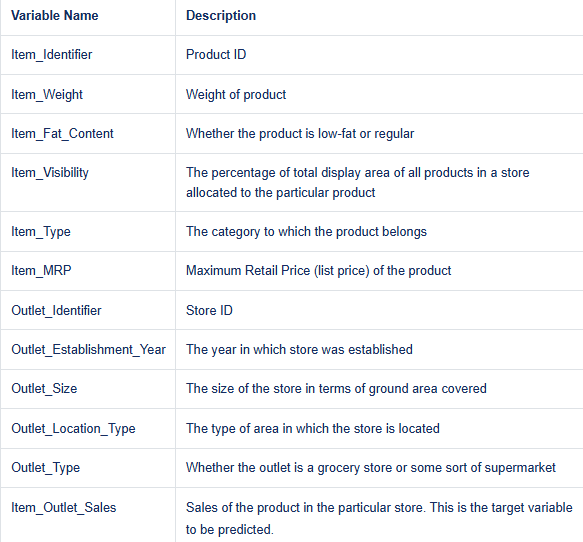

## Load and Inspect Data

In [2]:
#Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Import data
path="/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv"
import pandas as pd
df=pd.read_csv(path)
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


#Clean Data

In [ ]:
#Show the information of the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
#Check the number of rows and columns
df.shape

(8523, 12)

In [ ]:
#Check the data type for all variables
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [ ]:
#Check if there is any duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#Check null values
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [ ]:
#Show values count for Item_Weight column
df['Item_Weight'].value_counts()

,count
Item_Weight,
12.150,86
17.600,82
13.650,77
11.800,76
15.100,68
...,...
8.920,2
6.520,1
9.420,1


In [ ]:
#Fill the null values in Item_Weight column with "Unknown"
df['Item_Weight'].fillna("Unknown", inplace=True);
df['Item_Weight'].value_counts()

,count
Item_Weight,
Unknown,1463
12.15,86
17.6,82
13.65,77
11.8,76
...,...
5.21,2
9.42,1
7.685,1


In [ ]:
#Confirm there is no missing value in Item_Weight column
df['Item_Weight'].isna().sum()

np.int64(0)

In [ ]:
#Show values count for Outlet_Size column
df['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
Small,2388
High,932


In [ ]:
#Fill the null values in Outlet_Size coulmn with "Unknown"
df['Outlet_Size'].fillna("Unknown", inplace=True);
df['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
Unknown,2410
Small,2388
High,932


In [ ]:
#Confirm there is no missing values in Outlet_Size column
df['Outlet_Size'].isna().sum()

np.int64(0)

In [ ]:
#Make a list of objects columns in the data frame
str_cols=df.select_dtypes(include='object').columns
str_cols

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Type',
       'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type'],
      dtype='object')

In [ ]:
#Loop through the list to show value counts for each column
for col in str_cols:
  print(f"value count for {col}:")
  print(df[col].value_counts())
  print("\n")

value count for Item_Identifier:
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


value count for Item_Weight:
Item_Weight
Unknown    1463
12.15        86
17.6         82
13.65        77
11.8         76
           ... 
5.21          2
9.42          1
7.685         1
5.4           1
6.52          1
Name: count, Length: 416, dtype: int64


value count for Item_Fat_Content:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


value count for Item_Type:
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                 

In [ ]:
#Fixing data in Item_Fat_Content column and rename categories
df['Item_Fat_Content']=df['Item_Fat_Content'].replace('LF','Low Fat')
df['Item_Fat_Content']=df['Item_Fat_Content'].replace('reg','Regular')
df['Item_Fat_Content']=df['Item_Fat_Content'].replace('low fat','Low Fat')

In [ ]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [ ]:
stats =  df.describe()
stats.loc[['mean','min','max']]

,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
mean,0.066132,140.992782,1997.831867,2181.288914
min,0.000000,31.290000,1985.000000,33.290000
max,0.328391,266.888400,2009.000000,13086.964800


In [ ]:
#Saving the cleaned data to Google Drive
f_path="/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week02/Data/Cleaned_sales_predictions_2023.csv"
df.to_csv(f_path, index=False)

## Exploratory Data Analysis

In [4]:
#Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#loading the cleaned data for visualization
url="/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week02/Data/Cleaned_sales_predictions_2023.csv"
df=pd.read_csv(url)
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.3,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.5,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.2,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Unknown,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   object 
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 799.2+ KB


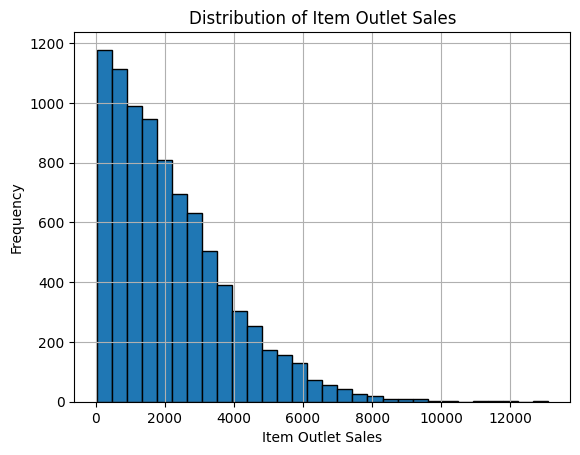

In [7]:
#Histogram for Item Outlet Sales column distribution
ax=df['Item_Outlet_Sales'].hist(bins=30, edgecolor='black')
ax.set_xlabel('Item Outlet Sales')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Item Outlet Sales');

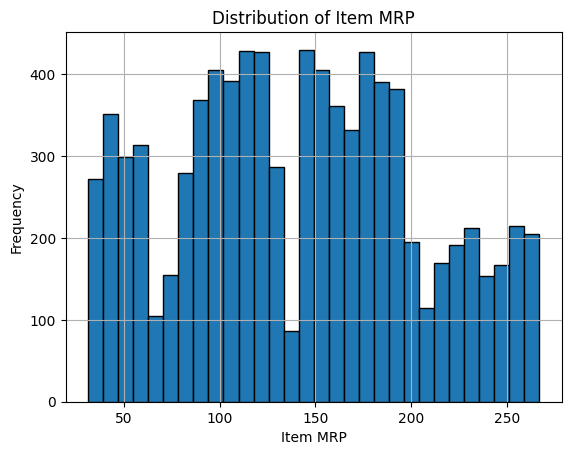

In [8]:
#Histogram to show the distribution of Item MRP column
ax=df['Item_MRP'].hist(bins=30, edgecolor='black')
ax.set_xlabel('Item MRP')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Item MRP');

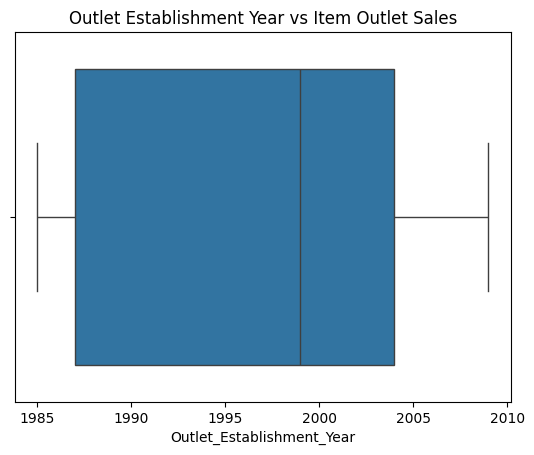

In [24]:
#Boxplot for Outlet_Establishment_Year column
ax=sns.boxplot(data=df,x='Outlet_Establishment_Year')
ax.set_title('Outlet Establishment Year vs Item Outlet Sales');

In [10]:
df.nunique()

,0
Item_Identifier,1559
Item_Weight,416
Item_Fat_Content,2
Item_Visibility,7880
Item_Type,16
Item_MRP,5938
Outlet_Identifier,10
Outlet_Establishment_Year,9
Outlet_Size,4
Outlet_Location_Type,3


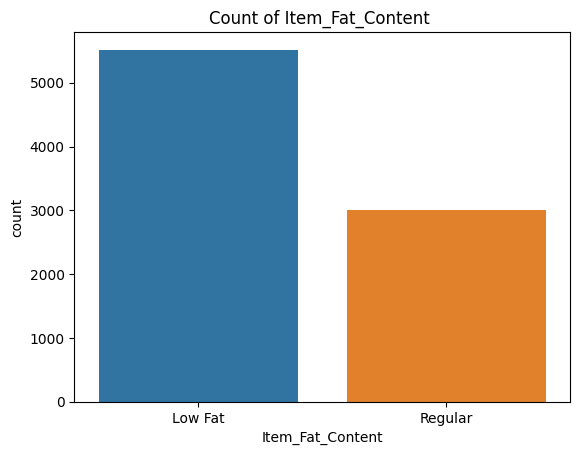

In [11]:
#Countplot of Item_Fat_Content feature
ax=sns.countplot(x="Item_Fat_Content", data=df, hue="Item_Fat_Content")
ax.set_title('Count of Item_Fat_Content ');

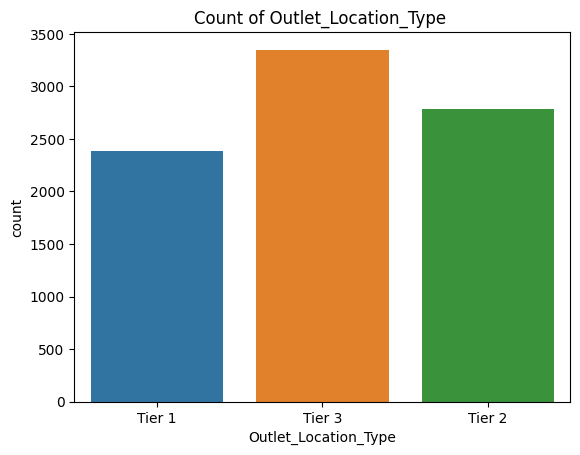

In [12]:
#Countplot of Outlet_Location_Type feature
ax=sns.countplot(x="Outlet_Location_Type", data=df, hue="Outlet_Location_Type")
ax.set_title('Count of Outlet_Location_Type ');

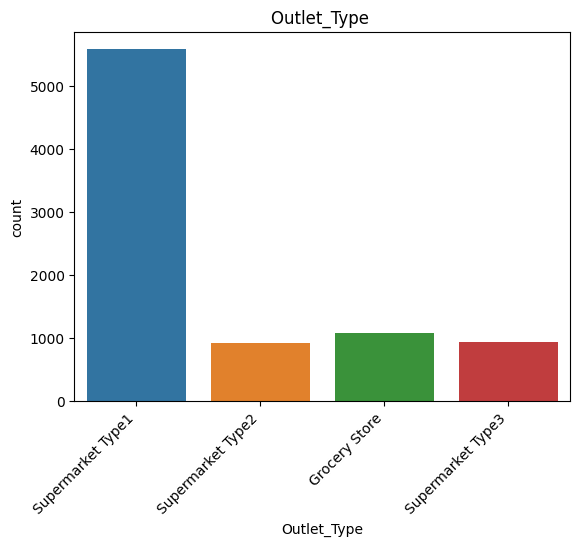

In [21]:
#Countplot of Outlet_Type feature
ax=sns.countplot(x="Outlet_Type", data=df, hue="Outlet_Type")
ax.set_title('Outlet_Type ');
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels( ax.get_xticklabels(),rotation=45, ha='right');

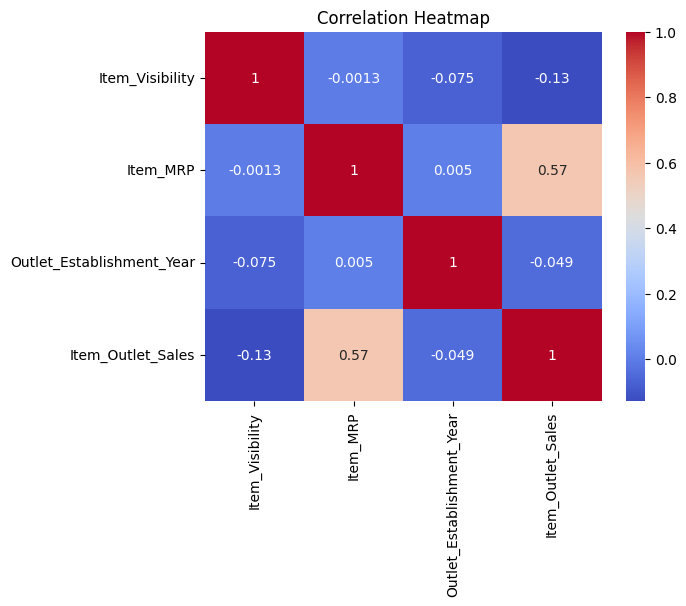

In [23]:
#Heatmap to view the correlation between features
corr=df.corr(numeric_only=True)
ax=sns.heatmap(corr, annot=True, cmap='coolwarm')
ax.set_title('Correlation Heatmap');

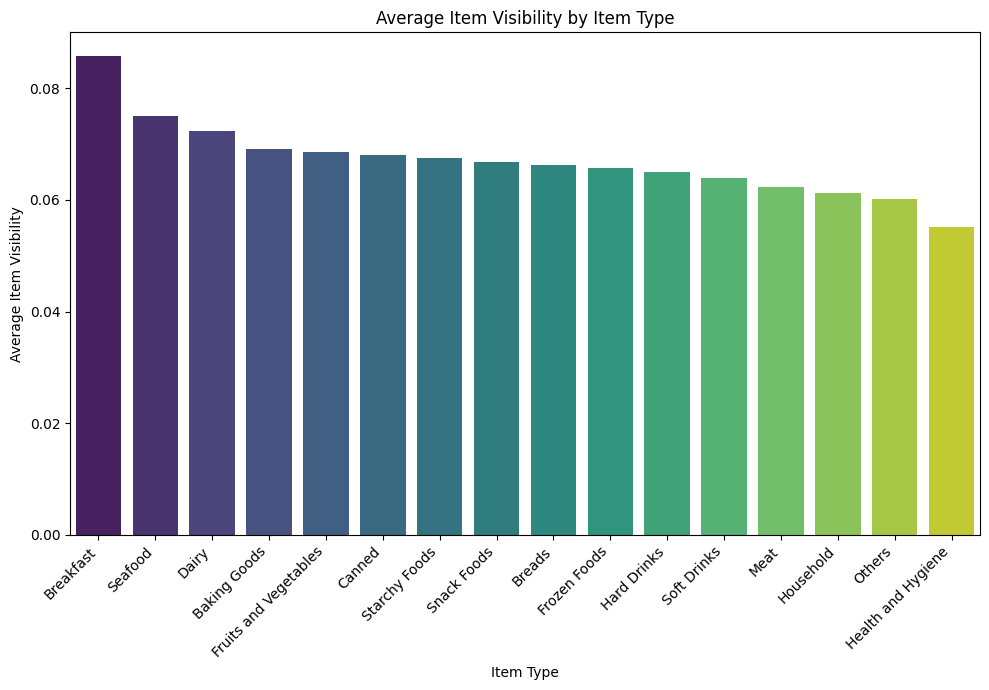

In [22]:
#Barplot to view the Average Item Visibility by Item Type

# Calculate the average Item_Visibility for each Item_Type
average_visibility_by_type = df.groupby('Item_Type')['Item_Visibility'].mean().sort_values(ascending=False).reset_index()

# Create a bar plot
plt.figure(figsize=(10, 7))
sns.barplot(x='Item_Type', y='Item_Visibility', data=average_visibility_by_type, hue='Item_Type', palette='viridis', legend=False)
plt.xlabel('Item Type')
plt.ylabel('Average Item Visibility')
plt.title('Average Item Visibility by Item Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Feature Inspection